In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sequence.kernel.timeline import Timeline
from sequence.topology.node import Node
from sequence.components.fiber_quantum_channel import (
    fiberQuantumChannel, FiberSpec, FiberSection)
from sequence.constants import PLANCK_CONSTANT, SPEED_OF_LIGHT_M_PER_S
from sequence.topology.optical_nodes import PolarizationAnalyzerNode

plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 22,
    'axes.titlesize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 16
})

colors = {
    1270: "#1f77b4",
    1310: "#2ca02c", 
    1330: "#9467bd",
    1490: "#ff7f0e",
}

def photons_to_mW(P_ph, wavelength_nm):
    h = PLANCK_CONSTANT
    c = SPEED_OF_LIGHT_M_PER_S
    lam = wavelength_nm * 1e-9
    E = h * c / lam
    return (P_ph * E) * 1e3

def get_attenuation_coefficient(wavelength_nm):
    attenuation_db_km = {
        1270: 0.34,
        1310: 0.32,
        1330: 0.28,
        1490: 0.19,
        1550: 0.17
    }
    if wavelength_nm in attenuation_db_km:
        alpha_db_km = attenuation_db_km[wavelength_nm]
    else:
        alpha_db_km = 0.17
    return alpha_db_km / 1000.0 * np.log(10) / 10

def get_beta_coefficients(classical_wl_nm, quantum_wl_nm=1550):
    beta_values = {
        1270: {'FS': 0.058e-23, 'BS': 0.061e-23},
        1310: {'FS': 0.421e-23, 'BS': 0.449e-23},
        1330: {'FS': 0.699e-23, 'BS': 0.745e-23},
        1490: {'FS': 3.69e-23, 'BS': 3.75e-23}
    }
    return beta_values[classical_wl_nm]['FS'], beta_values[classical_wl_nm]['BS']

def calculate_theoretical_raman(fiber_length_m, classical_wl_nm, quantum_wl_nm, 
                                classical_power_ph_s, quantum_bandwidth_Hz):
    alpha_s = get_attenuation_coefficient(classical_wl_nm)
    alpha_n = get_attenuation_coefficient(quantum_wl_nm)
    beta_FS, beta_BS = get_beta_coefficients(classical_wl_nm, quantum_wl_nm)
    
    L = fiber_length_m
    P_in = classical_power_ph_s
    delta_nu = quantum_bandwidth_Hz
    
    P_BS = ((1 - np.exp(-(alpha_s + alpha_n) * L)) / (alpha_s + alpha_n)) * beta_BS * delta_nu * P_in
    P_FS = ((np.exp(-alpha_n * L) - np.exp(-alpha_s * L)) / (alpha_s - alpha_n)) * beta_FS * delta_nu * P_in
    
    return P_FS, P_BS, P_FS + P_BS

In [2]:
def run_raman_simulation_power(
    fiber_length_m=25000,
    classical_wavelengths=[1270, 1310, 1330, 1490],
    launch_powers_photons_per_s=np.logspace(13, 15, 5),
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9
):
    results = {}
    
    for wl in classical_wavelengths:
        print(f"Simulating wavelength: {wl} nm")
        
        fs_rates = []
        bs_rates = []
        total_rates = []
        
        for P_ph in launch_powers_photons_per_s:
            P_mW = photons_to_mW(P_ph, wl)
            
            tl = Timeline()
            alice = Node("Alice", tl, seed=0)
            bob = Node("Bob", tl, seed=1)
            
            spec = FiberSpec(
                classical_coexist_enabled=True,
                classical_wavelength_nm=wl,
                quantum_wavelength_nm=quantum_wavelength_nm,
                quantum_bandwidth_Hz=quantum_bandwidth_Hz,
                classical_power_mW=P_mW,
            )
            
            channel = fiberQuantumChannel(
                name=f"fiber_{wl}_{P_ph}",
                timeline=tl,
                attenuation=0.17 / 1000.0,
                distance=fiber_length_m,
                sections=[FiberSection(fiber_length_m, spec)],
            )
            
            channel.set_ends(alice, bob.name)
            tl.init()
            
            fs_rates.append(channel.raman_noise_rate_FS_Hz)
            bs_rates.append(channel.raman_noise_rate_BS_Hz)
            total_rates.append(channel.raman_noise_rate_Hz)
        
        results[wl] = {
            'powers_photons_per_s': launch_powers_photons_per_s,
            'powers_mW': np.array([photons_to_mW(p, wl) for p in launch_powers_photons_per_s]),
            'fs_rates_Hz': np.array(fs_rates),
            'bs_rates_Hz': np.array(bs_rates),
            'total_rates_Hz': np.array(total_rates),
        }
    
    return results

model_results_power = run_raman_simulation_power(
    fiber_length_m=25000,
    classical_wavelengths=[1270, 1310, 1330, 1490],
    launch_powers_photons_per_s=np.array([1e13, 3e13, 1e14, 3e14, 1e15]),
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9
)

def simulate_experimental_data_power(model_results, noise_level=0.15):
    experimental_data = {}
    
    for wl in [1270, 1310, 1330, 1490]:
        model_data = model_results[wl]
        indices = [0, 1, 3, 4]
        
        powers_photons_per_s = np.array([model_data['powers_photons_per_s'][i] for i in indices])
        model_noise = np.array([model_data['total_rates_Hz'][i] for i in indices])
        
        np.random.seed(42 + wl)
        measured_noise = model_noise * (1 + noise_level * np.random.randn(len(indices)))
        uncertainties = model_noise * noise_level
        
        experimental_data[wl] = {
            'powers_photons_per_s': powers_photons_per_s,
            'measured_noise_Hz': measured_noise,
            'uncertainties_Hz': uncertainties,
        }
    
    return experimental_data

experimental_data_power = simulate_experimental_data_power(model_results_power, noise_level=0.15)

Simulating wavelength: 1270 nm
Simulating wavelength: 1310 nm
Simulating wavelength: 1330 nm
Simulating wavelength: 1490 nm


In [3]:
def run_raman_theoretical_power(
    fiber_length_m=25000,
    classical_wavelengths=[1270, 1310, 1330, 1490],
    launch_powers_photons_per_s=np.logspace(13, 15, 5),
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9
):
    results = {}
    
    for wl in classical_wavelengths:
        print(f"Calculating theoretical model for {wl} nm")
        
        fs_rates = []
        bs_rates = []
        total_rates = []
        
        for P_ph in launch_powers_photons_per_s:
            P_FS, P_BS, P_total = calculate_theoretical_raman(
                fiber_length_m, wl, quantum_wavelength_nm, P_ph, quantum_bandwidth_Hz
            )
            
            fs_rates.append(P_FS)
            bs_rates.append(P_BS)
            total_rates.append(P_total)
        
        results[wl] = {
            'powers_photons_per_s': launch_powers_photons_per_s,
            'powers_mW': np.array([photons_to_mW(p, wl) for p in launch_powers_photons_per_s]),
            'fs_rates_Hz': np.array(fs_rates),
            'bs_rates_Hz': np.array(bs_rates),
            'total_rates_Hz': np.array(total_rates),
        }
    
    return results

def simulate_raman_data_power(
    fiber_length_m=25000,
    classical_wavelengths=[1270, 1310, 1330, 1490],
    launch_powers_photons_per_s=np.array([1e13, 3e13, 1e14, 3e14, 1e15]),
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9,
    measurement_time_s=60.0
):
    experimental_data = {}
    indices = [0, 1, 3, 4]
    
    for wl in classical_wavelengths:
        print(f"Running simulation measurement for {wl} nm")
        
        measured_counts = []
        uncertainties = []
        
        for idx in indices:
            P_ph = launch_powers_photons_per_s[idx]
            P_mW = photons_to_mW(P_ph, wl)
            
            tl = Timeline(stop_time=measurement_time_s * 1e12)
            alice = Node("Alice", tl, seed=idx)
            bob = PolarizationAnalyzerNode("Bob", tl)
            
            spec = FiberSpec(
                classical_coexist_enabled=True,
                classical_wavelength_nm=wl,
                quantum_wavelength_nm=quantum_wavelength_nm,
                quantum_bandwidth_Hz=quantum_bandwidth_Hz,
                classical_power_mW=P_mW,
            )
            
            channel = fiberQuantumChannel(
                name=f"fiber_{wl}_{P_ph}",
                timeline=tl,
                attenuation=0.17 / 1000.0,
                distance=fiber_length_m,
                sections=[FiberSection(fiber_length_m, spec)],
            )
            
            channel.set_ends(alice, bob.name)
            tl.init()
            
            tl.run()
            
            total_counts = bob.classical_noise_count
            count_rate_Hz = total_counts / measurement_time_s
            uncertainty_Hz = np.sqrt(total_counts) / measurement_time_s
            
            measured_counts.append(count_rate_Hz)
            uncertainties.append(uncertainty_Hz)
        
        experimental_data[wl] = {
            'powers_photons_per_s': np.array([launch_powers_photons_per_s[i] for i in indices]),
            'measured_noise_Hz': np.array(measured_counts),
            'uncertainties_Hz': np.array(uncertainties),
        }
    
    return experimental_data

model_results_power = run_raman_theoretical_power(
    fiber_length_m=25000,
    classical_wavelengths=[1270, 1310, 1330, 1490],
    launch_powers_photons_per_s=np.array([1e13, 3e13, 1e14, 3e14, 1e15]),
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9
)

experimental_data_power = simulate_raman_data_power(
    fiber_length_m=25000,
    classical_wavelengths=[1270, 1310, 1330, 1490],
    launch_powers_photons_per_s=np.array([1e13, 3e13, 1e14, 3e14, 1e15]),
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9,
    measurement_time_s=1
)

Calculating theoretical model for 1270 nm
Calculating theoretical model for 1310 nm
Calculating theoretical model for 1330 nm
Calculating theoretical model for 1490 nm
Running simulation measurement for 1270 nm
Running simulation measurement for 1310 nm
Running simulation measurement for 1330 nm
Running simulation measurement for 1490 nm


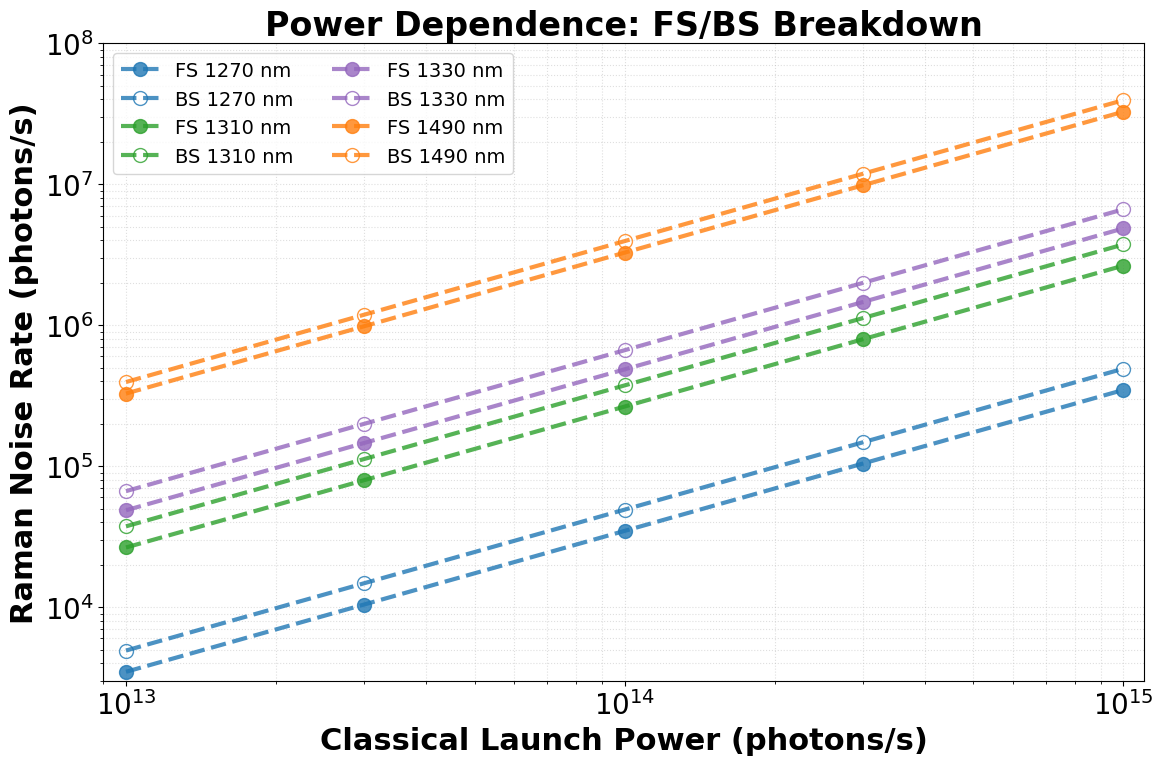

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

for wl, data in model_results_power.items():
    powers = data['powers_photons_per_s']
    
    ax.loglog(
        powers, data['fs_rates_Hz'],
        marker='o', linestyle='--', linewidth=3,
        color=colors[wl], label=f'FS {wl} nm',
        markersize=10, alpha=0.8
    )
    
    ax.loglog(
        powers, data['bs_rates_Hz'],
        marker='o', fillstyle='none', linestyle='--', linewidth=3,
        color=colors[wl], label=f'BS {wl} nm',
        markersize=10, alpha=0.8
    )

ax.set_xlabel('Classical Launch Power (photons/s)', fontweight='bold')
ax.set_ylabel('Raman Noise Rate (photons/s)', fontweight='bold')
ax.set_title('Power Dependence: FS/BS Breakdown', fontweight='bold')
ax.grid(True, which='both', ls=':', alpha=0.4)
ax.legend(ncol=2, fontsize=14, loc='upper left')
ax.set_xlim([9e12, 1.1e15])
ax.set_ylim([3e3, 1e8])
plt.tight_layout()
plt.show()

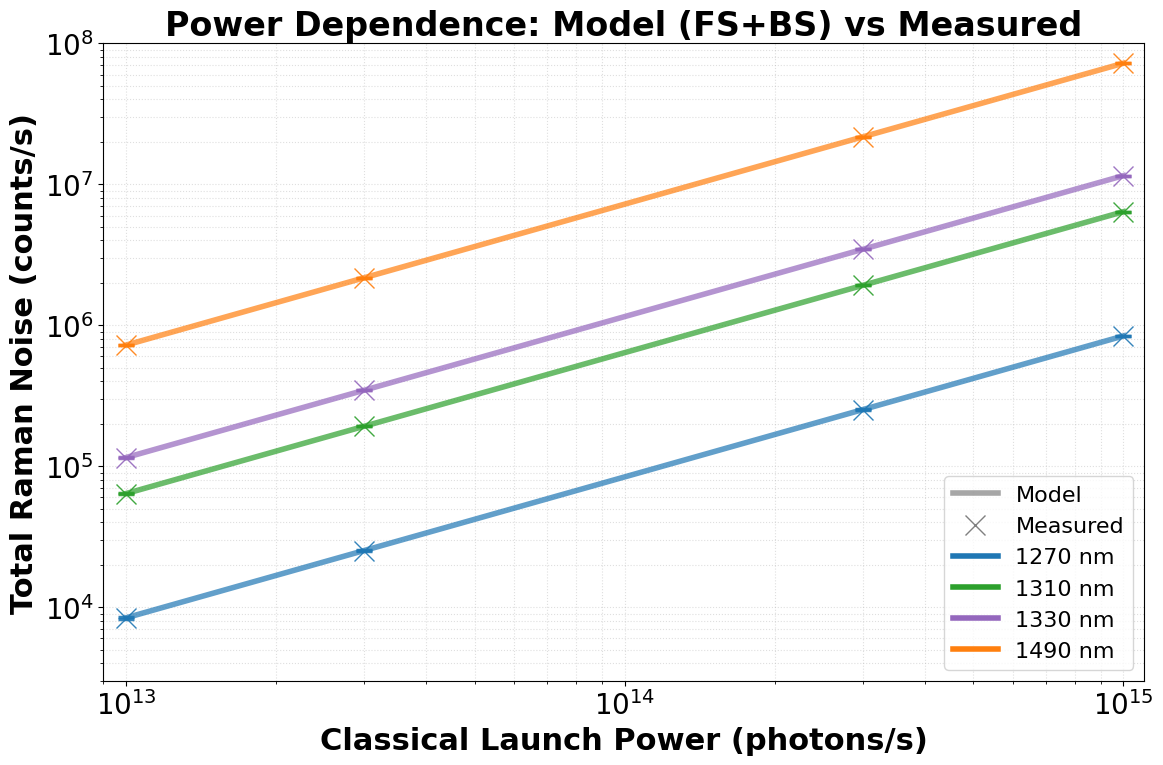

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

for wl in [1270, 1310, 1330, 1490]:
    model_data = model_results_power[wl]
    exp_data = experimental_data_power[wl]
    
    ax.loglog(
        model_data['powers_photons_per_s'], model_data['total_rates_Hz'],
        '-', linewidth=4, color=colors[wl], 
        label=f'{wl} nm', alpha=0.7
    )
    
    ax.errorbar(
        exp_data['powers_photons_per_s'], 
        exp_data['measured_noise_Hz'],
        yerr=exp_data['uncertainties_Hz'],
        fmt='x', markersize=14, linewidth=3, capsize=6, capthick=2.5,
        color=colors[wl], alpha=0.9
    )

from matplotlib.lines import Line2D
model_line = Line2D([0], [0], color='gray', linewidth=4, label='Model', alpha=0.7)
measured_marker = Line2D([0], [0], marker='x', color='gray', linewidth=0, 
                        markersize=14, label='Measured')

wl_1270 = Line2D([0], [0], color=colors[1270], linewidth=4, label='1270 nm')
wl_1310 = Line2D([0], [0], color=colors[1310], linewidth=4, label='1310 nm')
wl_1330 = Line2D([0], [0], color=colors[1330], linewidth=4, label='1330 nm')
wl_1490 = Line2D([0], [0], color=colors[1490], linewidth=4, label='1490 nm')

handles = [model_line, measured_marker, wl_1270, wl_1310, wl_1330, wl_1490]

ax.set_xlabel('Classical Launch Power (photons/s)', fontweight='bold')
ax.set_ylabel('Total Raman Noise (counts/s)', fontweight='bold')
ax.set_title('Power Dependence: Model (FS+BS) vs Measured', fontweight='bold')
ax.grid(True, which='both', ls=':', alpha=0.4)
ax.legend(handles=handles, fontsize=16, loc='lower right')
ax.set_xlim([9e12, 1.1e15])
ax.set_ylim([3e3, 1e8])
plt.tight_layout()
plt.show()

In [6]:
def run_raman_theoretical_distance(
    distances_km=[1,2,3,4, 6, 12.5, 25],
    classical_wavelengths=[1270, 1310, 1330, 1490],
    fixed_power_photons_per_s=1e14,
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9
):
    results = {}
    powers_mW = {wl: photons_to_mW(fixed_power_photons_per_s, wl) for wl in classical_wavelengths}
    
    for wl in classical_wavelengths:
        print(f"Calculating theoretical model for {wl} nm")
        
        fs_rates = []
        bs_rates = []
        total_rates = []
        
        for distance_km in distances_km:
            distance_m = distance_km * 1000
            
            P_FS, P_BS, P_total = calculate_theoretical_raman(
                distance_m, wl, quantum_wavelength_nm, fixed_power_photons_per_s, quantum_bandwidth_Hz
            )
            
            fs_rates.append(P_FS)
            bs_rates.append(P_BS)
            total_rates.append(P_total)
        
        results[wl] = {
            'distances_km': np.array(distances_km),
            'power_mW': powers_mW[wl],
            'fs_rates_Hz': np.array(fs_rates),
            'bs_rates_Hz': np.array(bs_rates),
            'total_rates_Hz': np.array(total_rates),
        }
    
    return results


def simulate_raman_data_distance(
    distances_km=[1, 6, 12.5, 25],
    classical_wavelengths=[1270, 1310, 1330, 1490],
    fixed_power_photons_per_s=1e14,
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9,
    measurement_time_s=1.0
):
    experimental_data = {}
    powers_mW = {wl: photons_to_mW(fixed_power_photons_per_s, wl) for wl in classical_wavelengths}
    
    for wl in classical_wavelengths:
        print(f"Running simulation measurement for {wl} nm")
        
        measured_counts = []
        uncertainties = []
        
        for idx, distance_km in enumerate(distances_km):
            distance_m = distance_km * 1000
            
            tl = Timeline(stop_time=measurement_time_s * 1e12)
            alice = Node("Alice", tl, seed=idx)
            bob = PolarizationAnalyzerNode("Bob", tl)
            
            spec = FiberSpec(
                classical_coexist_enabled=True,
                classical_wavelength_nm=wl,
                quantum_wavelength_nm=quantum_wavelength_nm,
                quantum_bandwidth_Hz=quantum_bandwidth_Hz,
                classical_power_mW=powers_mW[wl],
            )
            
            channel = fiberQuantumChannel(
                name=f"fiber_{wl}_{distance_km}km",
                timeline=tl,
                attenuation=0.17 / 1000.0,
                distance=distance_m,
                sections=[FiberSection(distance_m, spec)],
            )
            
            channel.set_ends(alice, bob.name)
            tl.init()
            
            tl.run()
            
            total_counts = bob.classical_noise_count
            count_rate_Hz = total_counts / measurement_time_s
            uncertainty_Hz = np.sqrt(total_counts) / measurement_time_s
            
            measured_counts.append(count_rate_Hz)
            uncertainties.append(uncertainty_Hz)
        
        experimental_data[wl] = {
            'distances_km': np.array(distances_km),
            'measured_noise_Hz': np.array(measured_counts),
            'uncertainties_Hz': np.array(uncertainties),
        }
    
    return experimental_data


model_results_distance = run_raman_theoretical_distance(
    distances_km=[1, 6, 12.5, 25],
    classical_wavelengths=[1270, 1310, 1330, 1490],
    fixed_power_photons_per_s=1e14,
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9
)


experimental_data_distance = simulate_raman_data_distance(
    distances_km=[1, 6, 12.5, 25],
    classical_wavelengths=[1270, 1310, 1330, 1490],
    fixed_power_photons_per_s=1e14,
    quantum_wavelength_nm=1550.0,
    quantum_bandwidth_Hz=100e9,
    measurement_time_s=0.1
)

Calculating theoretical model for 1270 nm
Calculating theoretical model for 1310 nm
Calculating theoretical model for 1330 nm
Calculating theoretical model for 1490 nm
Running simulation measurement for 1270 nm
Running simulation measurement for 1310 nm
Running simulation measurement for 1330 nm
Running simulation measurement for 1490 nm


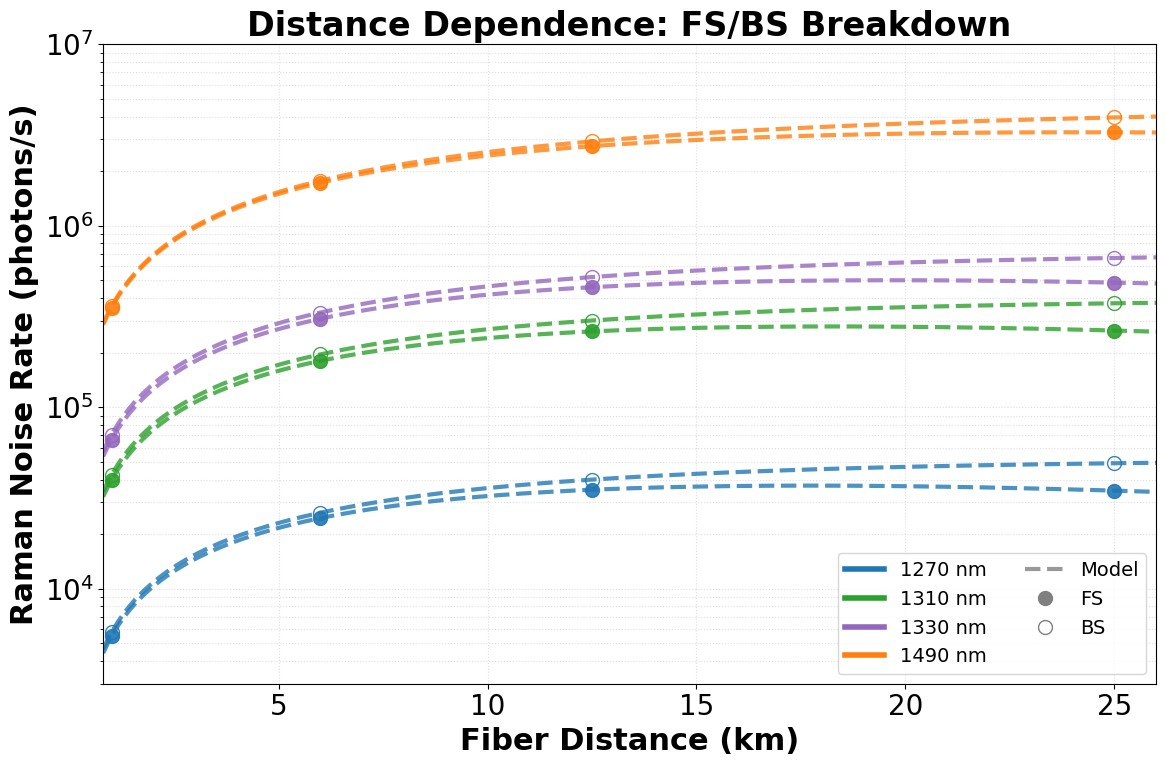

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

distances_fine = np.linspace(0.8, 26, 200)

for wl in [1270, 1310, 1330, 1490]:
    fs_rates_fine = []
    bs_rates_fine = []
    
    for dist_km in distances_fine:
        P_FS, P_BS, _ = calculate_theoretical_raman(
            dist_km * 1000, wl, 1550, 1e14, 100e9
        )
        fs_rates_fine.append(P_FS)
        bs_rates_fine.append(P_BS)
    
    ax.semilogy(
        distances_fine, fs_rates_fine,
        linestyle='--', linewidth=3,
        color=colors[wl],
        alpha=0.8
    )
    
    ax.semilogy(
        distances_fine, bs_rates_fine,
        linestyle='--', linewidth=3,
        color=colors[wl],
        alpha=0.8
    )

for wl, data in model_results_distance.items():
    distances = data['distances_km']
    
    ax.semilogy(
        distances, data['fs_rates_Hz'],
        marker='o', linestyle='none',
        color=colors[wl],
        markersize=10, alpha=0.9
    )
    
    ax.semilogy(
        distances, data['bs_rates_Hz'],
        marker='o', fillstyle='none', linestyle='none',
        color=colors[wl],
        markersize=10, alpha=0.9
    )

from matplotlib.lines import Line2D
model_line = Line2D([0], [0], color='gray', linestyle='--', linewidth=3, label='Model', alpha=0.8)
fs_marker = Line2D([0], [0], marker='o', color='gray', linestyle='none', 
                   markersize=10, label='FS', fillstyle='full')
bs_marker = Line2D([0], [0], marker='o', color='gray', linestyle='none', 
                   markersize=10, label='BS', fillstyle='none')

wl_1270 = Line2D([0], [0], color=colors[1270], linewidth=4, label='1270 nm')
wl_1310 = Line2D([0], [0], color=colors[1310], linewidth=4, label='1310 nm')
wl_1330 = Line2D([0], [0], color=colors[1330], linewidth=4, label='1330 nm')
wl_1490 = Line2D([0], [0], color=colors[1490], linewidth=4, label='1490 nm')

handles = [wl_1270, wl_1310, wl_1330, wl_1490, model_line, fs_marker, bs_marker]

ax.set_xlabel('Fiber Distance (km)', fontweight='bold')
ax.set_ylabel('Raman Noise Rate (photons/s)', fontweight='bold')
ax.set_title('Distance Dependence: FS/BS Breakdown', fontweight='bold')
ax.grid(True, which='both', ls=':', alpha=0.4)
ax.legend(handles=handles, ncol=2, fontsize=14, loc='lower right')
ax.set_xlim([0.8, 26])
ax.set_ylim([3e3, 1e7])
plt.tight_layout()
plt.show()


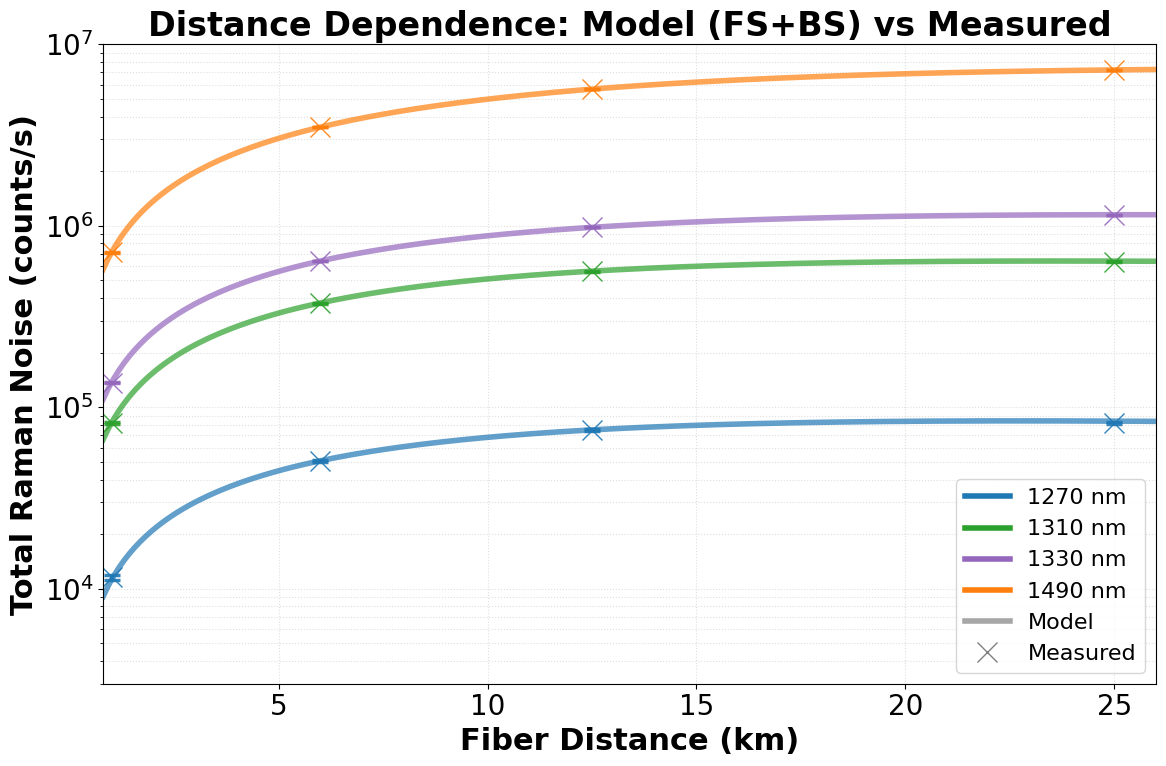

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

distances_fine = np.linspace(0.8, 26, 200)

for wl in [1270, 1310, 1330, 1490]:
    exp_data = experimental_data_distance[wl]
    
    model_rates_fine = []
    for dist_km in distances_fine:
        _, _, total = calculate_theoretical_raman(
            dist_km * 1000, wl, 1550, 1e14, 100e9
        )
        model_rates_fine.append(total)
    
    ax.semilogy(
        distances_fine, model_rates_fine,
        '-', linewidth=4, color=colors[wl], 
        alpha=0.7
    )
    
    ax.errorbar(
        exp_data['distances_km'], 
        exp_data['measured_noise_Hz'],
        yerr=exp_data['uncertainties_Hz'],
        fmt='x', markersize=14, linewidth=3, capsize=6, capthick=2.5,
        color=colors[wl], alpha=0.9
    )

from matplotlib.lines import Line2D
model_line = Line2D([0], [0], color='gray', linewidth=4, label='Model', alpha=0.7)
measured_marker = Line2D([0], [0], marker='x', color='gray', linewidth=0, 
                        markersize=14, label='Measured')

wl_1270 = Line2D([0], [0], color=colors[1270], linewidth=4, label='1270 nm')
wl_1310 = Line2D([0], [0], color=colors[1310], linewidth=4, label='1310 nm')
wl_1330 = Line2D([0], [0], color=colors[1330], linewidth=4, label='1330 nm')
wl_1490 = Line2D([0], [0], color=colors[1490], linewidth=4, label='1490 nm')

handles = [wl_1270, wl_1310, wl_1330, wl_1490, model_line, measured_marker]

ax.set_xlabel('Fiber Distance (km)', fontweight='bold')
ax.set_ylabel('Total Raman Noise (counts/s)', fontweight='bold')
ax.set_title('Distance Dependence: Model (FS+BS) vs Measured', fontweight='bold')
ax.grid(True, which='both', ls=':', alpha=0.4)
ax.legend(handles=handles, fontsize=16, loc='lower right')
ax.set_xlim([0.8, 26])
ax.set_ylim([3e3, 1e7])
plt.tight_layout()
plt.show()
